# Chapter 10: neural learning about edges and corners: intro to convolutional neural networks

Haikal Ali TK-46-GAB 1103223071

## In this chapter

- Reusing weights in multiple places
- The convolutional layer

## Reusing weights in multiple places

Jika perlu mendeteksi feature yang sama di banyak tempat, gunakan weights yang sama.

Tantangan besar dalam neural networks adalah overfitting, yaitu ketika network menghafal dataset, bukan mempelajari abstraction yang berguna untuk data baru. Overfitting sering terjadi ketika jumlah parameters terlalu banyak dibanding jumlah datapoints yang tersedia.

Pada image classification, network bisa saja menghafal detail tertentu dari training image, bukan mempelajari ciri umum seperti edge, corner, atau shape. Jika network memiliki banyak parameters tetapi hanya sedikit training examples, overfitting menjadi sulit dihindari.

Regularization sudah dibahas sebagai salah satu cara melawan overfitting. Namun, ada cara lain yang lebih struktural: menggunakan **structure**.

Structure berarti memilih untuk memakai ulang weights untuk beberapa tujuan dalam network karena pattern yang sama perlu dideteksi di banyak tempat. Cara ini dapat mengurangi overfitting karena menurunkan rasio jumlah weights terhadap jumlah datapoints.

Jika reuse weights dilakukan pada tempat yang tepat, model bisa tetap expressive, lebih robust terhadap overfitting, dan lebih kecil karena jumlah parameters yang disimpan lebih sedikit.

Structure paling terkenal dan banyak digunakan dalam neural networks disebut **convolution**. Jika digunakan sebagai layer, disebut **convolutional layer**.

## The convolutional layer

Convolutional layer menggunakan banyak linear layer kecil yang dipakai ulang di setiap posisi, bukan satu dense linear layer besar.

Inti convolutional layer adalah mengganti dense layer besar yang menghubungkan setiap input ke setiap output dengan banyak linear layer kecil. Linear layer kecil ini biasanya memiliki kurang dari 25 inputs dan satu output.

Mini-layer ini disebut **convolutional kernel**. Secara konsep, convolutional kernel hanyalah linear layer kecil dengan sedikit input dan satu output.

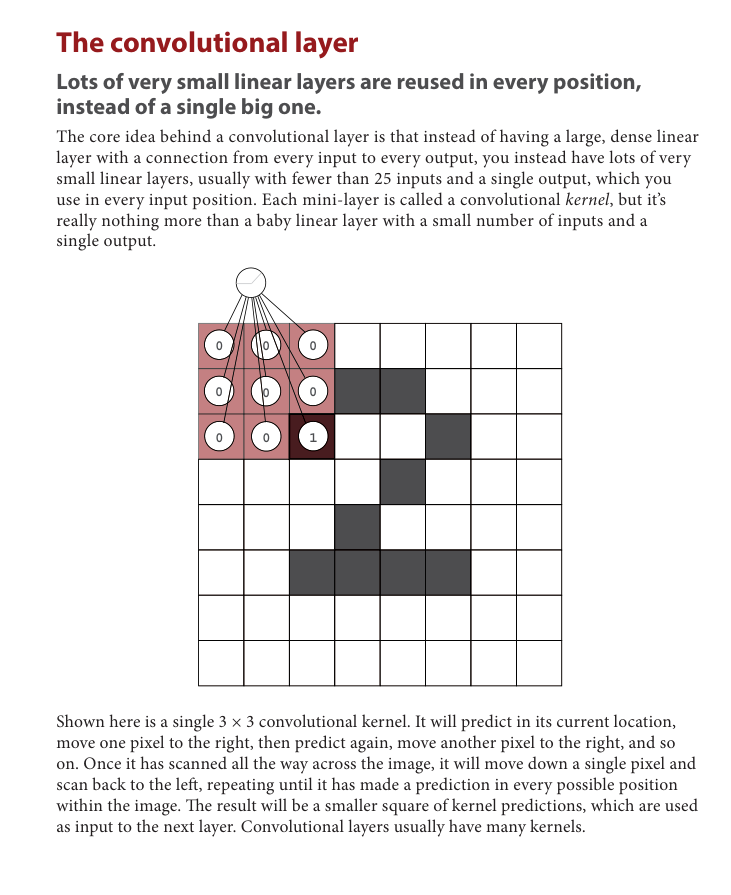

Contoh pada gambar memakai satu kernel 3 × 3. Kernel membuat prediction pada lokasi saat ini, lalu bergeser satu pixel ke kanan dan membuat prediction lagi. Setelah selesai memindai satu baris, kernel turun satu pixel dan mengulangi prosesnya.

Hasilnya adalah matrix prediction yang lebih kecil. Pada contoh image 8 × 8 dengan kernel 3 × 3, setiap kernel menghasilkan prediction matrix 6 × 6. Convolutional layer biasanya memiliki banyak kernels.

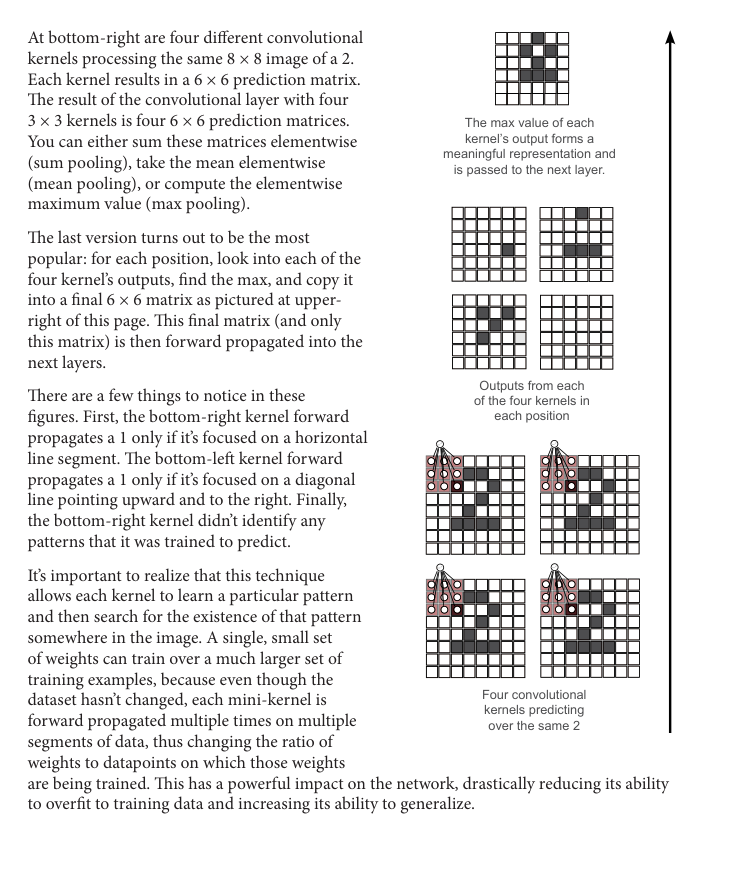

Pada contoh lain, empat convolutional kernels memproses image 8 × 8 yang sama. Setiap kernel menghasilkan prediction matrix 6 × 6. Jika ada empat kernel 3 × 3, hasil convolutional layer adalah empat prediction matrices berukuran 6 × 6.

Beberapa cara menggabungkan output kernels adalah:

- **sum pooling**: menjumlahkan matrices secara elementwise.
- **mean pooling**: mengambil rata-rata elementwise.
- **max pooling**: mengambil nilai maksimum elementwise.

Versi yang paling populer adalah max pooling. Untuk setiap posisi, nilai maksimum dari output kernels diambil dan disalin ke final matrix. Matrix akhir ini kemudian diforward-propagate ke layer berikutnya.

Teknik ini membuat setiap kernel belajar pattern tertentu, lalu mencari keberadaan pattern tersebut di seluruh image. Satu set weights kecil dapat dilatih pada lebih banyak potongan data karena kernel yang sama digunakan berulang kali pada banyak bagian image.

Hal ini mengubah rasio weights terhadap datapoints, mengurangi kemampuan network untuk overfit, dan meningkatkan kemampuan generalization.

## A simple implementation in NumPy

Implementasi convolution dapat dipahami sebagai banyak mini-linear layers.

Langkah pertama adalah mengambil subregion dari batch image. Function berikut mengambil bagian tertentu dari semua image dalam batch.

In [1]:
import numpy as np

def get_image_section(layer, row_from, row_to, col_from, col_to):
  section = layer[:, row_from:row_to, col_from:col_to]
  return section.reshape(-1, 1, row_to - row_from, col_to - col_from)

Pada potongan buku, function mengembalikan `subsection`, padahal variabel yang dibuat bernama `section`. Notebook ini memakai `section` agar kode dapat berjalan.

Untuk memakai function tersebut, setiap lokasi valid pada image perlu dipindai. Setiap subregion dikumpulkan, lalu di-reshape agar setiap subregion diperlakukan seperti image kecil sendiri.

In [2]:
import numpy as np

sample_images = np.arange(2 * 5 * 5).reshape(2, 5, 5)
kernel_rows = 3
kernel_cols = 3

sects = []

for row_start in range(sample_images.shape[1] - kernel_rows + 1):
  for col_start in range(sample_images.shape[2] - kernel_cols + 1):
    sect = get_image_section(
      sample_images,
      row_start,
      row_start + kernel_rows,
      col_start,
      col_start + kernel_cols
    )
    sects.append(sect)

expanded_input = np.concatenate(sects, axis=1)
es = expanded_input.shape
flattened_input = expanded_input.reshape(es[0] * es[1], -1)

print("sample_images shape:", sample_images.shape)
print("expanded_input shape:", expanded_input.shape)
print("flattened_input shape:", flattened_input.shape)

sample_images shape: (2, 5, 5)
expanded_input shape: (2, 9, 3, 3)
flattened_input shape: (18, 9)


Jika batch size berisi 8 images dan ada 100 subregions per image, maka subregions tersebut dapat diperlakukan seperti batch berisi 800 image kecil. Forward propagation melalui linear layer dengan satu output neuron sama seperti menjalankan kernel pada setiap subregion.

Jika linear layer memiliki `n` output neurons, hasilnya sama seperti memprediksi `n` kernels pada setiap posisi input image.

In [3]:
num_kernels = 4
kernels = np.random.random((kernel_rows * kernel_cols, num_kernels))

kernel_output = flattened_input.dot(kernels)

print("kernels shape:", kernels.shape)
print("kernel_output shape:", kernel_output.shape)

kernels shape: (9, 4)
kernel_output shape: (18, 4)


## Full NumPy implementation

Kode berikut adalah implementasi convolutional neural network sederhana menggunakan NumPy pada MNIST.

Penyesuaian agar kode bisa berjalan:

- Import memakai `tensorflow.keras.datasets` agar cocok dengan Google Colab.
- `get_image_section` memakai `section`, bukan `subsection`.
- Sliding window memakai `+1` agar mencakup semua posisi valid. Ini sesuai dengan penjelasan bahwa image 8 × 8 dengan kernel 3 × 3 menghasilkan output 6 × 6.
- Forward pass testing memakai `softmax` agar konsisten dengan output activation.
- Update `kernels` memakai arah yang konsisten dengan `layer_2_delta = labels - layer_2`.
- Evaluasi test ditampilkan setiap 10 iterasi agar tidak terlalu berat saat dijalankan di Colab.

In [4]:
import sys
import numpy as np
from tensorflow.keras.datasets import mnist

np.random.seed(1)

(x_train, y_train), (x_test, y_test) = mnist.load_data()

images = x_train[0:1000].reshape(1000, 28 * 28) / 255
labels = y_train[0:1000]

one_hot_labels = np.zeros((len(labels), 10))

for i, l in enumerate(labels):
  one_hot_labels[i][l] = 1

labels = one_hot_labels

test_images = x_test.reshape(len(x_test), 28 * 28) / 255

test_labels = np.zeros((len(y_test), 10))

for i, l in enumerate(y_test):
  test_labels[i][l] = 1

def tanh(x):
  return np.tanh(x)

def tanh2deriv(output):
  return 1 - (output ** 2)

def softmax(x):
  temp = np.exp(x)
  return temp / np.sum(temp, axis=1, keepdims=True)

def get_image_section(layer, row_from, row_to, col_from, col_to):
  section = layer[:, row_from:row_to, col_from:col_to]
  return section.reshape(-1, 1, row_to - row_from, col_to - col_from)

def image_sections_to_rows(layer_0, kernel_rows, kernel_cols):
  sects = []

  for row_start in range(layer_0.shape[1] - kernel_rows + 1):
    for col_start in range(layer_0.shape[2] - kernel_cols + 1):
      sect = get_image_section(
        layer_0,
        row_start,
        row_start + kernel_rows,
        col_start,
        col_start + kernel_cols
      )
      sects.append(sect)

  expanded_input = np.concatenate(sects, axis=1)
  es = expanded_input.shape
  flattened_input = expanded_input.reshape(es[0] * es[1], -1)

  return expanded_input, flattened_input

def forward_conv_batch(flat_images, kernels, weights_1_2, kernel_rows, kernel_cols):
  layer_0 = flat_images.reshape(flat_images.shape[0], 28, 28)
  expanded_input, flattened_input = image_sections_to_rows(layer_0, kernel_rows, kernel_cols)
  es = expanded_input.shape

  kernel_output = flattened_input.dot(kernels)
  layer_1 = tanh(kernel_output.reshape(es[0], -1))
  layer_2 = softmax(np.dot(layer_1, weights_1_2))

  return layer_0, expanded_input, flattened_input, kernel_output, layer_1, layer_2

alpha, iterations = (2, 300)
pixels_per_image, num_labels = (784, 10)
batch_size = 128

input_rows = 28
input_cols = 28
kernel_rows = 3
kernel_cols = 3
num_kernels = 16

output_rows = input_rows - kernel_rows + 1
output_cols = input_cols - kernel_cols + 1
hidden_size = output_rows * output_cols * num_kernels

kernels = 0.02 * np.random.random((kernel_rows * kernel_cols, num_kernels)) - 0.01
weights_1_2 = 0.2 * np.random.random((hidden_size, num_labels)) - 0.1

for j in range(iterations):
  correct_cnt = 0

  for i in range(int(len(images) / batch_size)):
    batch_start = i * batch_size
    batch_end = (i + 1) * batch_size

    flat_batch = images[batch_start:batch_end]
    label_batch = labels[batch_start:batch_end]

    layer_0, expanded_input, flattened_input, kernel_output, layer_1, layer_2 = forward_conv_batch(
      flat_batch,
      kernels,
      weights_1_2,
      kernel_rows,
      kernel_cols
    )

    dropout_mask = np.random.randint(2, size=layer_1.shape)
    layer_1 *= dropout_mask * 2

    layer_2 = softmax(np.dot(layer_1, weights_1_2))

    for k in range(batch_size):
      labelset = labels[batch_start + k:batch_start + k + 1]
      correct_cnt += int(np.argmax(layer_2[k:k + 1]) == np.argmax(labelset))

    layer_2_delta = (label_batch - layer_2) / (batch_size * layer_2.shape[0])
    layer_1_delta = layer_2_delta.dot(weights_1_2.T) * tanh2deriv(layer_1)
    layer_1_delta *= dropout_mask

    weights_1_2 += alpha * layer_1.T.dot(layer_2_delta)

    l1d_reshape = layer_1_delta.reshape(kernel_output.shape)
    k_update = flattened_input.T.dot(l1d_reshape)
    kernels += alpha * k_update

  if j % 10 == 0 or j == iterations - 1:
    test_correct_cnt = 0

    for test_start in range(0, len(test_images), batch_size):
      test_end = min(test_start + batch_size, len(test_images))
      flat_test_batch = test_images[test_start:test_end]

      _, _, _, _, test_layer_1, test_layer_2 = forward_conv_batch(
        flat_test_batch,
        kernels,
        weights_1_2,
        kernel_rows,
        kernel_cols
      )

      for k in range(test_end - test_start):
        test_correct_cnt += int(
          np.argmax(test_layer_2[k:k + 1]) ==
          np.argmax(test_labels[test_start + k:test_start + k + 1])
        )

    print(
      "I:" + str(j) +
      " Test-Acc:" + str(test_correct_cnt / float(len(test_images))) +
      " Train-Acc:" + str(correct_cnt / float(len(images)))
    )

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
I:0 Test-Acc:0.1762 Train-Acc:0.122
I:10 Test-Acc:0.4798 Train-Acc:0.353
I:20 Test-Acc:0.7094 Train-Acc:0.563
I:30 Test-Acc:0.7791 Train-Acc:0.654
I:40 Test-Acc:0.8071 Train-Acc:0.688
I:50 Test-Acc:0.8221 Train-Acc:0.726
I:60 Test-Acc:0.8341 Train-Acc:0.743
I:70 Test-Acc:0.8405 Train-Acc:0.74
I:80 Test-Acc:0.8464 Train-Acc:0.751
I:90 Test-Acc:0.849 Train-Acc:0.768
I:100 Test-Acc:0.8523 Train-Acc:0.785
I:110 Test-Acc:0.8553 Train-Acc:0.766
I:120 Test-Acc:0.8576 Train-Acc:0.776
I:130 Test-Acc:0.8599 Train-Acc:0.792
I:140 Test-Acc:0.8614 Train-Acc:0.785
I:150 Test-Acc:0.8619 Train-Acc:0.799
I:160 Test-Acc:0.863 Train-Acc:0.806
I:170 Test-Acc:0.8638 Train-Acc:0.8
I:180 Test-Acc:0.8628 Train-Acc:0.808
I:190 Test-Acc:0.8638 Train-Acc:0.81
I:200 Test-Acc:0.8636 Train-Acc:0.811
I:210 Test-Acc:0.8651 Train-Acc:0.807
I:220 Test-Acc:0.8646 Train-Acc:0.814
I:230 Test-Acc:0.8641 Train-Acc:0.815
I:240 Test-Acc:0.8649 Train-Acc:0.819
I:250 Test-Acc:0

Dengan mengganti first layer dari network sebelumnya menjadi convolutional layer, error dapat turun beberapa persen lagi. Output convolutional layer (`kernel_output`) sendiri adalah rangkaian image dua dimensi, yaitu output dari setiap kernel pada setiap posisi input.

Sebagian besar penggunaan convolutional layers menumpuk beberapa convolutional layers. Setiap convolutional layer berikutnya memperlakukan output layer sebelumnya sebagai input image.

## Summary

Reusing weights adalah salah satu inovasi penting dalam deep learning.

Convolutional neural networks memakai ulang weights untuk mendeteksi pattern yang sama di banyak tempat. Untuk mendeteksi kucing dalam image, network perlu memahami colors, lines, edges, corners, small shapes, lalu kombinasi fitur yang lebih tinggi. Intelligence untuk mendeteksi lines dan edges dipelajari dalam weights.

Jika bagian image yang berbeda dianalisis dengan weights yang berbeda, setiap bagian harus belajar sendiri apa itu line. Convolution menghindari masalah ini dengan memakai weights yang sama di banyak lokasi.

**The structure trick:** ketika neural network perlu memakai ide yang sama di banyak tempat, usahakan memakai weights yang sama di tempat-tempat tersebut. Ini membuat weights lebih pintar karena mendapat lebih banyak samples untuk dipelajari, sehingga generalization meningkat.

Convolutions, recurrent neural networks, word embeddings, dan capsule networks dapat dilihat melalui ide reuse weights ini.